Datasets loaded successfully!
Total rows after merging and cleaning: 327


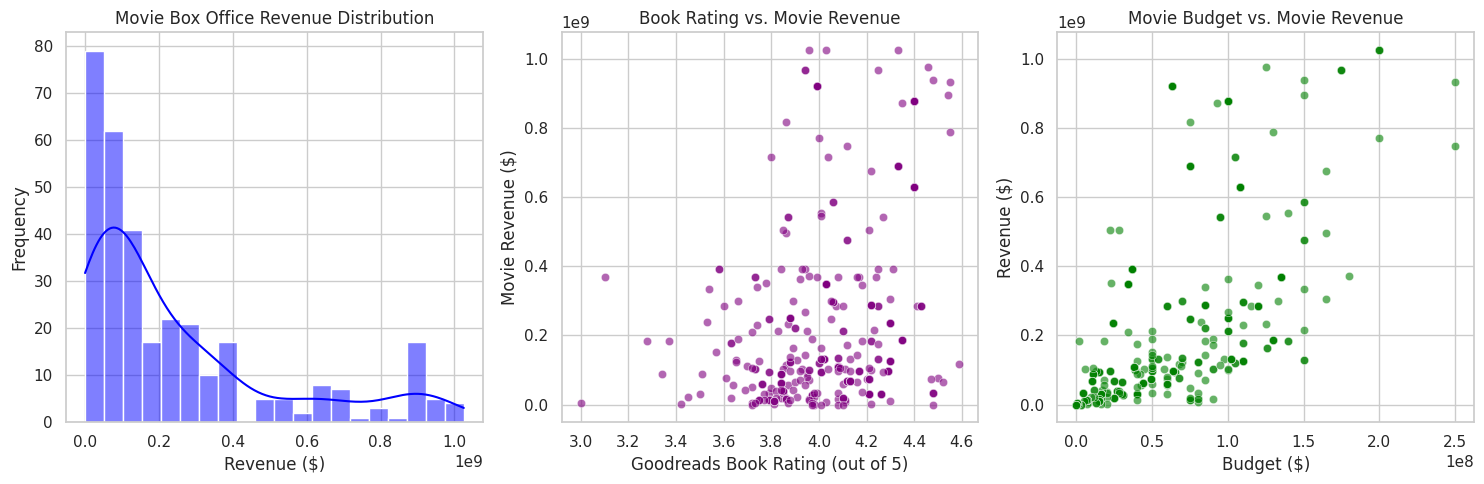


--- HYPOTHESIS TESTING ---
Number of High-Rated Book Adaptations: 178
Number of Low-Rated Book Adaptations: 149
T-Statistic: 3.9139
P-Value: 0.0001
Result: Since P-value < 0.05, we REJECT the Null Hypothesis.
Conclusion: The box office revenue of film adaptations of high-rated books is statistically significantly DIFFERENT from low-rated ones.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


# 1. DATA COLLECTION & PREPARATION


try:
    movies_df = pd.read_csv('tmdb_5000_movies.csv')
    books_df = pd.read_csv('books.csv')
    print("Datasets loaded successfully!")
except FileNotFoundError:
    print("ERROR: Please make sure the csv files are in the same directory as the code.")

# Filter for Science Fiction and Fantasy movies
sf_fantasy_movies = movies_df[movies_df['genres'].str.contains('Science Fiction|Fantasy', na=False)]

# Handling title mismatches (Mapping) as promised in the proposal
title_mapping = {
    "The Lord of the Rings: The Fellowship of the Ring": "The Fellowship of the Ring",
    "Harry Potter and the Philosopher's Stone": "Harry Potter and the Sorcerer's Stone"
}
sf_fantasy_movies['mapped_title'] = sf_fantasy_movies['title'].replace(title_mapping)

# Merge the two datasets (CHANGED 'title' to 'book_title')
merged_df = pd.merge(sf_fantasy_movies, books_df, left_on='mapped_title', right_on='book_title', how='inner')

# Clean unnecessary or missing (NaN) data (CHANGED 'average_rating' to 'book_rating')
merged_df = merged_df.dropna(subset=['revenue', 'budget', 'book_rating'])
merged_df = merged_df[merged_df['revenue'] > 0]
merged_df = merged_df[merged_df['budget'] > 0]

print(f"Total rows after merging and cleaning: {len(merged_df)}")


# 2. EXPLORATORY DATA ANALYSIS (EDA)


sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

#Distribution of Movie Box Office Revenue
plt.subplot(1, 3, 1)
sns.histplot(merged_df['revenue'], bins=20, kde=True, color='blue')
plt.title('Movie Box Office Revenue Distribution')
plt.xlabel('Revenue ($)')
plt.ylabel('Frequency')

#Goodreads Book Rating vs. Movie Revenue (CHANGED 'average_rating' to 'book_rating')
plt.subplot(1, 3, 2)
sns.scatterplot(data=merged_df, x='book_rating', y='revenue', alpha=0.6, color='purple')
plt.title('Book Rating vs. Movie Revenue')
plt.xlabel('Goodreads Book Rating (out of 5)')
plt.ylabel('Movie Revenue ($)')

#Movie Budget vs. Movie Revenue
plt.subplot(1, 3, 3)
sns.scatterplot(data=merged_df, x='budget', y='revenue', alpha=0.6, color='green')
plt.title('Movie Budget vs. Movie Revenue')
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')

plt.tight_layout()
plt.show()


# 3. HYPOTHESIS TESTING

print("\n--- HYPOTHESIS TESTING ---")

# Split the data into two groups based on book rating (CHANGED 'average_rating' to 'book_rating')
high_rated_books = merged_df[merged_df['book_rating'] >= 4.0]['revenue']
low_rated_books = merged_df[merged_df['book_rating'] < 4.0]['revenue']

print(f"Number of High-Rated Book Adaptations: {len(high_rated_books)}")
print(f"Number of Low-Rated Book Adaptations: {len(low_rated_books)}")

# Independent Two-Sample T-Test
t_stat, p_value = stats.ttest_ind(high_rated_books, low_rated_books, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# Interpret the result
alpha = 0.05
if p_value < alpha:
    print("Result: Since P-value < 0.05, we REJECT the Null Hypothesis.")
    print("Conclusion: The box office revenue of film adaptations of high-rated books is statistically significantly DIFFERENT from low-rated ones.")
else:
    print("Result: Since P-value >= 0.05, we FAIL TO REJECT the Null Hypothesis.")
    print("Conclusion: A high book rating DOES NOT make a statistically significant difference in the movie's box office revenue.")